Settings

In [1]:
DATASET = "all_cards"
NUM_EPOCHS = 2

Read data manifest

In [2]:
import pandas as pd

df = pd.read_csv(f"data/{DATASET}_manifest.csv")
print(f"Total cards: {len(df)}")
print(df.head())
print(df["types"].value_counts().head(20))

Total cards: 15248
                        illustration_id        types                  name  \
0  2fcca987-364c-4738-a75b-099d8a26d614       Sliver           Fury Sliver   
1  e8a09f86-98f6-46df-bf53-46a9f4117f36   Cat|Spirit  Spirit of the Hearth   
2  f5fa472f-6a19-4297-a0b6-bd67022284c8       Zombie  Lord of the Accursed   
3  9f52bc56-433e-4316-b11f-4abb005bc119  Human|Rogue       Shardless Agent   
4  d098436d-6360-4a84-bea3-e380de9449aa       Insect         Drudge Beetle   

                                          image_path  
0  data\all_cards\2fcca987-364c-4738-a75b-099d8a2...  
1  data\all_cards\e8a09f86-98f6-46df-bf53-46a9f41...  
2  data\all_cards\f5fa472f-6a19-4297-a0b6-bd67022...  
3  data\all_cards\9f52bc56-433e-4316-b11f-4abb005...  
4  data\all_cards\d098436d-6360-4a84-bea3-e380de9...  
types
Human|Wizard     682
Human|Soldier    635
Spirit           461
Elemental        430
Human|Cleric     371
Human|Knight     358
Dragon           358
Human|Warrior    356
Beast   

Build dataset

In [3]:
from PIL import Image
from torch.utils.data import Dataset
import torch


class CreatureDataset(Dataset):
    def __init__(self, df, all_types, transform=None):
        self.df = df.reset_index(drop=True)
        self.all_types = all_types
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        label = torch.zeros(len(self.all_types))
        types = row["types"].split("|") if isinstance(row["types"], str) else []
        for t in types:
            if t in self.all_types:
                label[self.all_types.index(t)] = 1.0
        
        return image, label

In [4]:
all_types = sorted(set(
    t for types_str in df["types"] if isinstance(types_str, str) for t in types_str.strip().split("|")
))
print(all_types)
print(f"amount of creature types:", len(all_types))

['Advisor', 'Ally', 'Angel', 'Archer', 'Artificer', 'Assassin', 'Avatar', 'Beast', 'Berserker', 'Bird', 'Cat', 'Cleric', 'Construct', 'Demon', 'Dinosaur', 'Dog', 'Dragon', 'Drake', 'Druid', 'Dwarf', 'Elder', 'Eldrazi', 'Elemental', 'Elf', 'Faerie', 'Giant', 'Goblin', 'God', 'Golem', 'Horror', 'Human', 'Illusion', 'Insect', 'Knight', 'Lizard', 'Merfolk', 'Minotaur', 'Monk', 'Mutant', 'Ninja', 'Noble', 'Ogre', 'Orc', 'Phyrexian', 'Pirate', 'Rat', 'Rogue', 'Scout', 'Shaman', 'Shapeshifter', 'Sliver', 'Snake', 'Soldier', 'Spider', 'Spirit', 'Treefolk', 'Turtle', 'Vampire', 'Wall', 'Warlock', 'Warrior', 'Wizard', 'Wolf', 'Wurm', 'Zombie']
amount of creature types: 65


In [5]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torchvision import transforms
import random

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# create a fixed train/val split
indices = list(range(len(df)))
split = int(0.8 * len(df))
random.shuffle(indices)
train_indices = indices[:split]
val_indices = indices[split:]
train_dataset = CreatureDataset(df.iloc[train_indices], all_types, transform=train_transform)
val_dataset = CreatureDataset(df.iloc[val_indices], all_types, transform=val_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 12198
Validation samples: 3050


In [6]:
from torch.utils.data import WeightedRandomSampler
from collections import Counter

# compute weight for each card
def compute_sample_weights(df, all_types, type_counts):
    weights = []
    for _, row in df.iterrows():
        if isinstance(row["types"], str):
            types = row["types"].split("|")
            # weight by inverse frequency of rarest type
            rarest_count = min(type_counts[t] for t in types)
            weights.append(1.0 / rarest_count)
        else:
            weights.append(1.0)
    return weights

type_counts = Counter(
    t for types_str in df["types"]
    if isinstance(types_str, str)
    for t in types_str.split("|")
)



In [8]:
import numpy as np

n_types = len(all_types)
type_to_idx = {t: i for i, t in enumerate(all_types)}

cooccurrence = np.zeros((n_types, n_types))
for _, row in df.iterrows():
    if not isinstance(row["types"], str):
        continue
    types = row["types"].split("|")
    for t1 in types:
        for t2 in types:
            if t1 in type_to_idx and t2 in type_to_idx:
                cooccurrence[type_to_idx[t1]][type_to_idx[t2]] += 1

normalized = np.zeros((n_types, n_types))
for i in range(n_types):
    if cooccurrence[i, i] > 0:
        normalized[i, :] = cooccurrence[i, :] / cooccurrence[i, i]

In [9]:
def compute_sample_weights(df, all_types, type_counts, normalized, cap_ratio=3.0):
    weights = []
    for _, row in df.iterrows():
        types = row["types"].split("|") if isinstance(row["types"], str) else []
        
        # base weight from inverse frequency
        base = sum(1.0 / type_counts[t] for t in types if t in type_counts)
        if not base:
            base = 1.0
        
        # correlation penalty from pairwise co-occurrence
        if len(types) > 1:
            pairs = [
                normalized[all_types.index(t1)][all_types.index(t2)]
                for t1 in types for t2 in types
                if t1 != t2 and t1 in all_types and t2 in all_types
            ]
            penalty = 1.0 + sum(pairs) / len(pairs)
        else:
            penalty = 1.0
        
        weights.append(base / penalty)
    
    # apply cap ratio
    min_w = min(weights)
    max_w = min_w * cap_ratio
    weights = [min(w, max_w) for w in weights]
    
    return weights

weights = compute_sample_weights(df.iloc[train_indices], all_types, type_counts, normalized)
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=128, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

[('Human', 4360), ('Warrior', 1238), ('Wizard', 1231), ('Soldier', 1019), ('Elf', 805), ('Spirit', 738), ('Cleric', 674), ('Zombie', 659), ('Goblin', 637), ('Elemental', 631), ('Dragon', 573), ('Shaman', 551), ('Knight', 543), ('Vampire', 540), ('Rogue', 528), ('Beast', 470), ('Bird', 459), ('Phyrexian', 438), ('Druid', 425), ('Merfolk', 370), ('Angel', 366), ('Cat', 354), ('Horror', 317), ('Scout', 299), ('Insect', 294), ('Construct', 284), ('Artificer', 277), ('Giant', 273), ('Demon', 268), ('Dinosaur', 240), ('Noble', 215), ('Golem', 195), ('Avatar', 193), ('Snake', 189), ('Assassin', 189), ('Faerie', 187), ('Shapeshifter', 186), ('Ninja', 182), ('Mutant', 181), ('Wall', 179), ('Warlock', 179), ('Pirate', 177), ('Ally', 177), ('Advisor', 171), ('Lizard', 165), ('Berserker', 161), ('Dwarf', 149), ('Monk', 148), ('Dog', 143), ('Rat', 141), ('Sliver', 140), ('Ogre', 134), ('Wurm', 131), ('Treefolk', 130), ('Eldrazi', 128), ('Turtle', 127), ('Orc', 125), ('Drake', 125), ('God', 117), ('

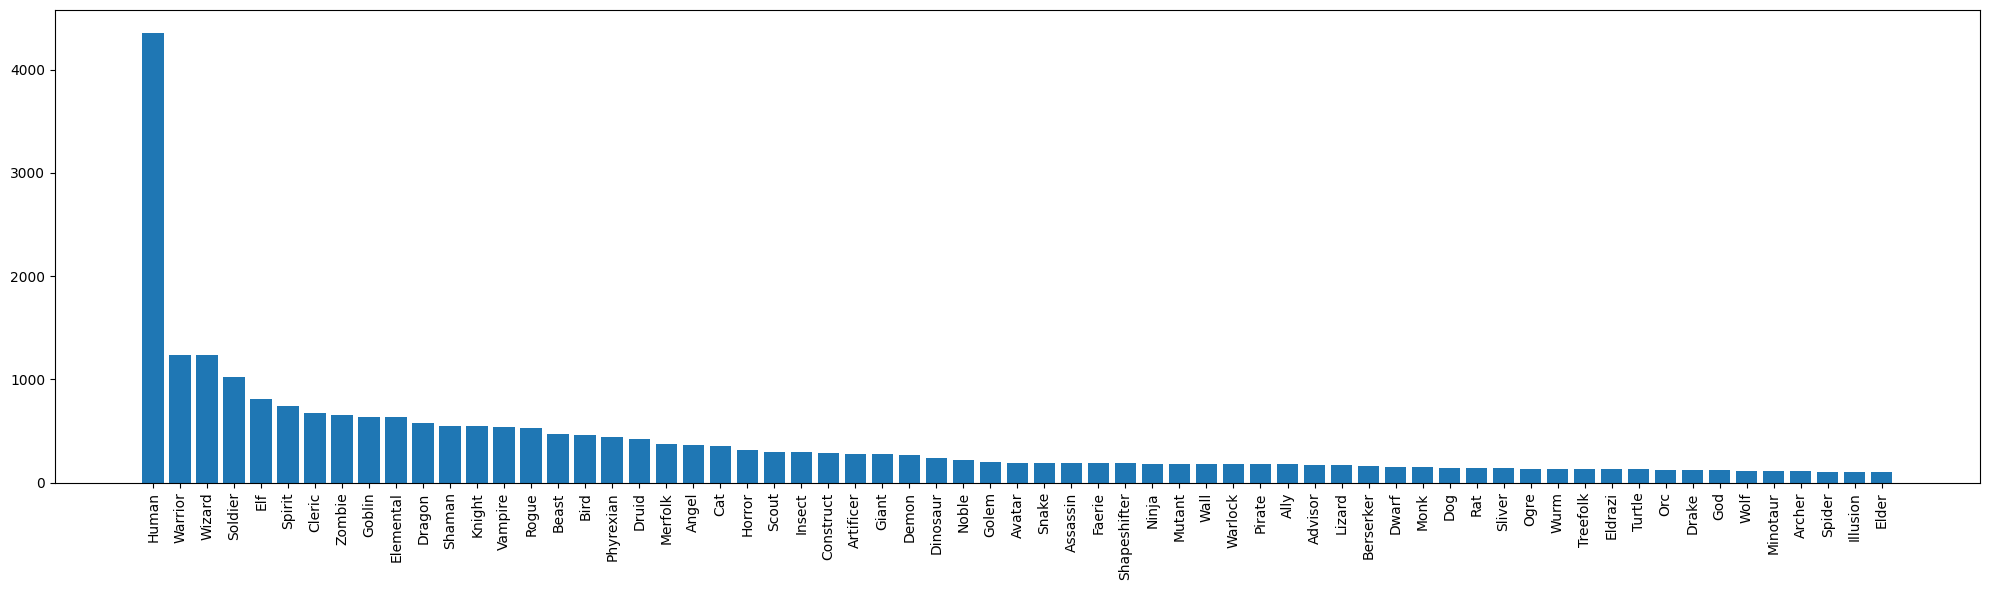

In [10]:
import matplotlib.pyplot as plt

types_sorted = sorted(type_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*types_sorted)

print(types_sorted)

plt.figure(figsize=(20, 6))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Model

In [12]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

# Torch settings
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False
torch.backends.cuda.matmul.allow_tf32 = True

# Device choice
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(torch.__version__)
print(torch.version.cuda)

# Model choice
# model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
# num_features = model.classifier[1].in_features
# model.classifier[1] = nn.Linear(num_features, len(all_types))
model = torch.load("models/v1_epoch_50.pth", map_location=device, weights_only=False)["model"].to(device)
print(model)

# we freeze all except the last layer
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

# Optimize
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam([
    {'params': model.features[6].parameters(), 'lr': 1e-5},
    {'params': model.features[7].parameters(), 'lr': 2e-5},
    {'params': model.features[8].parameters(), 'lr': 5e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Using device: cuda
2.7.1+cu118
11.8
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
        

Training

In [13]:
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from pathlib import Path

for epoch in range(1, NUM_EPOCHS + 1):
    # train
    model.train()
    train_loss = 0.0
    scaler = torch.amp.GradScaler('cuda')
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} train"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    # validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} val"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        print(f"Epoch {epoch}/{NUM_EPOCHS} — train loss: {avg_train_loss:.4f} — val loss: {avg_val_loss:.4f}")
    
    # unfreeze layers at threshold
    if epoch == 1 * NUM_EPOCHS // 5:
        print("unfreezing layer features[8]")
        for param in model.features[8].parameters():
            param.requires_grad = True
    if epoch == 2 * NUM_EPOCHS // 5:
        print("unfreezing layer features[7]")
        for param in model.features[7].parameters():
            param.requires_grad = True
    if epoch == 3 * NUM_EPOCHS // 5:
        print("unfreezing layer features[6]")
        for param in model.features[6].parameters():
            param.requires_grad = True

    # save model after epoch
    path = Path(f"models/checkpoint_epoch_{epoch}.pth")
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        'model': model,
        'all_types': all_types,
        'epoch': epoch,
        'val_loss': avg_val_loss,
    }, path)

Epoch 1/2 val: 100%|██████████| 24/24 [00:36<00:00,  1.51s/it]


Epoch 1/2 — train loss: 0.0742 — val loss: 0.0694
unfreezing layer features[6]


Epoch 2/2 train:  31%|███▏      | 30/96 [01:00<02:12,  2.01s/it]


KeyboardInterrupt: 